In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [3]:
import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax.random as jrandom
import optax  # pip install optax
from dataset.dataset import initialize_datasets, Dataset_PEPBI
from functions.model import AFF_PREDICTOR,stripped_PREDICTOR, combined_PREDICTOR
from functions.training import train_model, eval_step, train_model_validation, train_model_validation_combined
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.random as jr
import jax
import pandas as pd
from torch.utils.data import DataLoader, RandomSampler, random_split
import jax.tree_util as jtu
from functions import plots

In [4]:
base_path = '/home/kunzj'
#base_path = '"/home/jkunz/master_uni_hd/internship_amsterdam'

pepbi dataset

In [ ]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/pepbi/min_max_scaled/train_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# train_loader = DataLoader(data_train,batch_size=20)
# sns.kdeplot(data_train.aff_Vals)val_losses = [x.item() for x in val_losses]

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/pepbi/min_max_scaled/test_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# test_loader = DataLoader(data_test,batch_size=1)
# test_key_init = jrandom.PRNGKey(1)

mmpbsa dataset - cosine similarity

In [8]:
data_mmpbsa_all = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/finished_data_cosine_sim.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_train = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/split/finished_data_cosine_sim_train.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_validation = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/split/finished_data_cosine_sim_validation.csv",
    transform=esm2quinox.tokenise
)

data_mmpbsa_train_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_train.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_validation_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_validation.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_test_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_test.csv",
    transform=esm2quinox.tokenise
)


mmpbsa_all_data_loader = DataLoader(data_mmpbsa_all,batch_size=1)
mmpbsa_train_data_loader = DataLoader(data_mmpbsa_train,batch_size=3)
mmpbsa_validation_data_loader = DataLoader(data_mmpbsa_validation,batch_size=1)


mmpbsa_train_data_loader_three_split = DataLoader(data_mmpbsa_train_three_split,batch_size=3)
mmpbsa_validation_data_loader_three_split = DataLoader(data_mmpbsa_validation_three_split,batch_size=1)
mmpbsa_test_data_loader_three_split = DataLoader(data_mmpbsa_test_three_split,batch_size=1)

<Axes: ylabel='Count'>

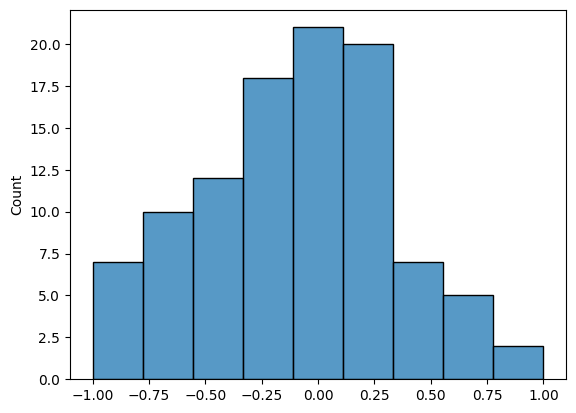

In [26]:
sns.histplot(data_mmpbsa_all.aff_Vals)

In [12]:
t=pd.read_csv('../../data/mmpbsa/md_data_all_binders_scaled_standard.csv')

In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler(feature_range=(-1,1))

In [21]:
sc_test = scaler.fit_transform(t[['energies']])

<Axes: ylabel='Count'>

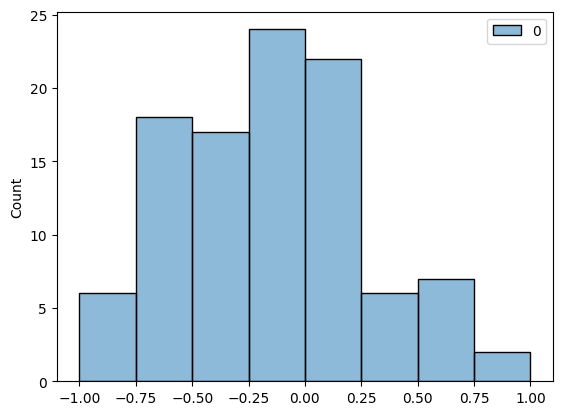

In [22]:
sns.histplot(sc_test)

<Axes: ylabel='Count'>

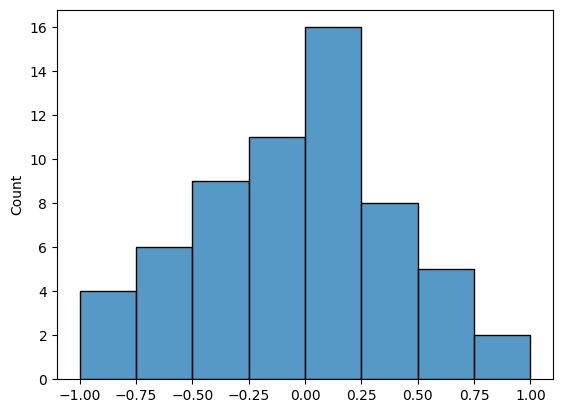

In [9]:
sns.histplot(data_mmpbsa_train_three_split.aff_Vals)

<Axes: ylabel='Count'>

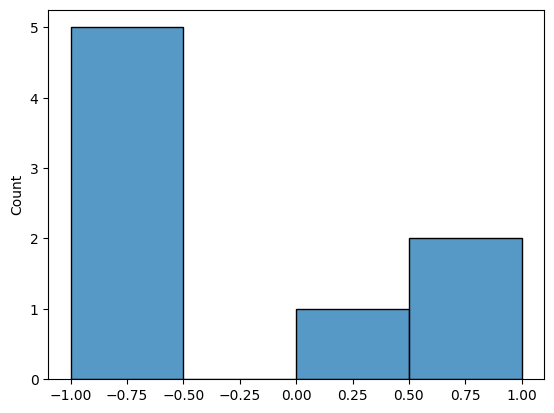

In [10]:
sns.histplot(data_mmpbsa_validation_three_split.aff_Vals)

<Axes: ylabel='Count'>

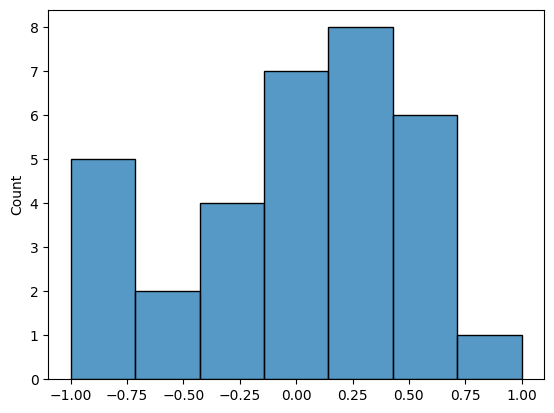

In [11]:
sns.histplot(data_mmpbsa_test_three_split.aff_Vals)

weird dataset

In [ ]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/train.csv",
#     transform=esm2quinox.tokenise,
# )
# train_loader = DataLoader(data_train, batch_size=20)


# data_validation = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/validation.csv",
#     transform=esm2quinox.tokenise,
# )
# validation_loader = DataLoader(data_validation, batch_size=1)

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/test.csv",
#     transform=esm2quinox.tokenise,
# )
# test_loader = DataLoader(data_test, batch_size=1)

# test_key_init = jrandom.PRNGKey(1)

weird dataset - cosine similarity


In [5]:
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/train.csv",
    transform=esm2quinox.tokenise,
)
train_loader = DataLoader(data_train, batch_size=20)



data_validation = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/validation.csv",
    transform=esm2quinox.tokenise,
)
validation_loader = DataLoader(data_validation, batch_size=1)

data_test = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/test.csv",
    transform=esm2quinox.tokenise,
)
test_loader = DataLoader(data_test, batch_size=1)

test_key_init = jrandom.PRNGKey(1)

W1125 15:16:26.933079   99307 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1125 15:16:26.935126   99308 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1125 15:16:26.939834   99069 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1125 15:16:26.941309   99069 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


<Axes: ylabel='Count'>

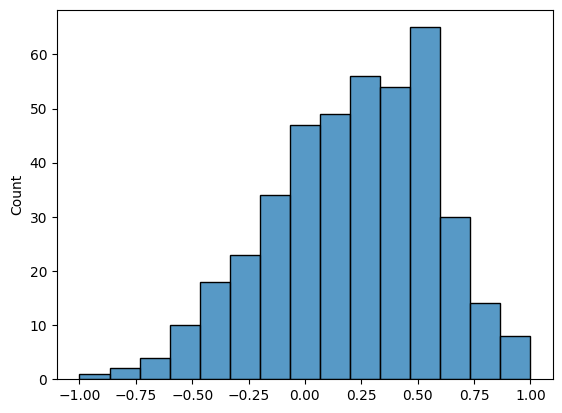

In [6]:
sns.histplot(data_train.aff_Vals)

<Axes: ylabel='Count'>

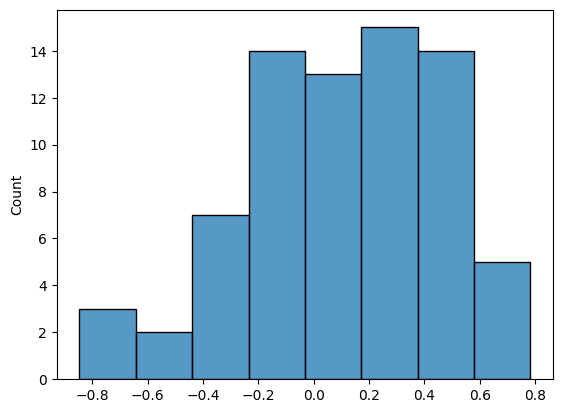

In [7]:
sns.histplot(data_validation.aff_Vals)

model initilialization

In [7]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))


In [23]:
model_esm2.layers

TransformerLayer(
  embed_size=640,
  hidden_size=2560,
  num_heads=20,
  attn=MultiheadAttention(
    query_proj=Linear(
      weight=f32[30,640,640],
      bias=f32[30,640],
      in_features=640,
      out_features=640,
      use_bias=True
    ),
    key_proj=Linear(
      weight=f32[30,640,640],
      bias=f32[30,640],
      in_features=640,
      out_features=640,
      use_bias=True
    ),
    value_proj=Linear(
      weight=f32[30,640,640],
      bias=f32[30,640],
      in_features=640,
      out_features=640,
      use_bias=True
    ),
    output_proj=Linear(
      weight=f32[30,640,640],
      bias=f32[30,640],
      in_features=640,
      out_features=640,
      use_bias=True
    ),
    dropout=Dropout(p=0.0, inference=False),
    num_heads=20,
    query_size=640,
    key_size=640,
    value_size=640,
    output_size=640,
    qk_size=32,
    vo_size=32,
    use_query_bias=True,
    use_key_bias=True,
    use_value_bias=True,
    use_output_bias=True
  ),
  rotary_embed=Rotary

In [ ]:
esm.pretrained.esm2

stripped_PREDICTOR(
  esm2=ESM2(
    num_layers=30,
    embed_size=640,
    num_heads=20,
    token_dropout=True,
    layers=TransformerLayer(
      embed_size=640,
      hidden_size=2560,
      num_heads=20,
      attn=MultiheadAttention(
        query_proj=Linear(
          weight=f32[30,640,640],
          bias=f32[30,640],
          in_features=640,
          out_features=640,
          use_bias=True
        ),
        key_proj=Linear(
          weight=f32[30,640,640],
          bias=f32[30,640],
          in_features=640,
          out_features=640,
          use_bias=True
        ),
        value_proj=Linear(
          weight=f32[30,640,640],
          bias=f32[30,640],
          in_features=640,
          out_features=640,
          use_bias=True
        ),
        output_proj=Linear(
          weight=f32[30,640,640],
          bias=f32[30,640],
          in_features=640,
          out_features=640,
          use_bias=True
        ),
        dropout=Dropout(p=0.0, inference=Fals

In [ ]:
model_esm2

In [ ]:
# eqx.tree_serialise_leaves('/home/jkunz/master_uni_hd/internship_amsterdam/carbon/BindCraft_uva_internship/notebooks/test.txt',model_aff)

In [ ]:
target_str =['QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSECLKRIGDELDSNMELQRMIAAVDTDSPREVFFRVAADMFSDGNFNWGRVVALFYFASKLVLKALCTKVPELIRTIMGWTLDFLRERLLGWIQDQGGWDGLLSYFG']
x_prot = esm2quinox.tokenise(target_str)
test_key = model_key[0]

In [ ]:
jax.vmap(model_esm2)(x_prot)

train model

In [ ]:
# train model
best_model, model_state, train_losses = train_model(
    training_DataLoader=train_loader,
    max_epochs=5,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

train model with validation

In [8]:
best_model, model_state, train_losses, val_losses = train_model_validation(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=10,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]
















Epochs:  10%|█         | 1/10 [00:58<08:47, 58.62s/it]

[Epoch 1] Train Loss: 0.130219, Val Loss: 0.001382
	(New best model saved.)
















Epochs:  20%|██        | 2/10 [01:11<04:12, 31.55s/it]

[Epoch 2] Train Loss: 0.091918, Val Loss: 0.003577
	(New best model saved.)


...















Epochs:  80%|████████  | 8/10 [02:26<00:27, 13.81s/it]

[Epoch 8] Train Loss: 0.031719, Val Loss: 0.002188
















Epochs:  90%|█████████ | 9/10 [02:39<00:13, 13.43s/it]

[Epoch 9] Train Loss: 0.026142, Val Loss: 0.000180


[Epoch 10] Train Loss: 0.019930, Val Loss: 0.001148
Training complete.


In [ ]:
best_model, model_state, train_losses, val_losses = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader_three_split,
    validation_Dataloader=mmpbsa_validation_data_loader_three_split,
    max_epochs=100,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

train combined_model with validation 

In [ ]:
best_model, model_state, train_losses, val_losses = train_model_validation_combined(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=1,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

In [ ]:
best_model, model_state, train_losses, val_losses = train_model_validation_combined(
    training_DataLoader=mmpbsa_train_data_loader,
    validation_Dataloader=mmpbsa_validation_data_loader,
    max_epochs=15,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

test

In [9]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(test_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 0.000, Predicted Y: 0.317, , True Y: 0.315
[Entry 2] , Test Loss: 0.001, Predicted Y: 0.666, , True Y: 0.641
[Entry 3] , Test Loss: 0.000, Predicted Y: 0.457, , True Y: 0.452
[Entry 4] , Test Loss: 0.152, Predicted Y: 0.610, , True Y: 0.220
[Entry 5] , Test Loss: 0.001, Predicted Y: 0.172, , True Y: 0.207
[Entry 6] , Test Loss: 0.003, Predicted Y: 0.197, , True Y: 0.254
[Entry 7] , Test Loss: 0.146, Predicted Y: 0.145, , True Y: -0.237
[Entry 8] , Test Loss: 0.055, Predicted Y: 0.315, , True Y: 0.080
[Entry 9] , Test Loss: 0.213, Predicted Y: 0.124, , True Y: 0.585
[Entry 10] , Test Loss: 0.013, Predicted Y: 0.134, , True Y: 0.018
[Entry 11] , Test Loss: 0.086, Predicted Y: 0.404, , True Y: 0.111
[Entry 12] , Test Loss: 0.040, Predicted Y: 0.238, , True Y: 0.438
[Entry 13] , Test Loss: 0.116, Predicted Y: 0.168, , True Y: 0.510
[Entry 14] , Test Loss: 0.182, Predicted Y: 0.248, , True Y: -0.178
[Entry 15] , Test Loss: 0.177, Predicted Y: 0.187, , True Y: -0.234
[

In [ ]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(mmpbsa_all_data_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


In [ ]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(mmpbsa_test_data_loader_three_split):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


<Axes: >

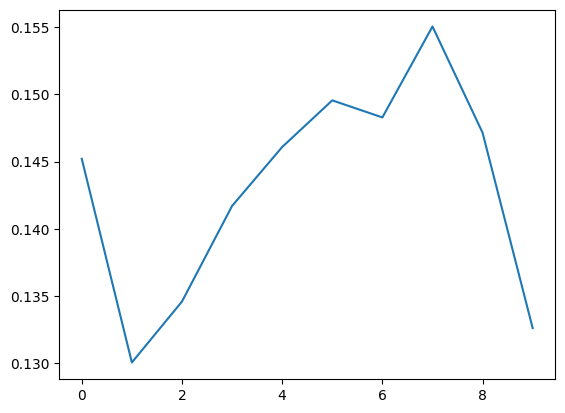

In [10]:

sns.lineplot(val_losses)

<Axes: >

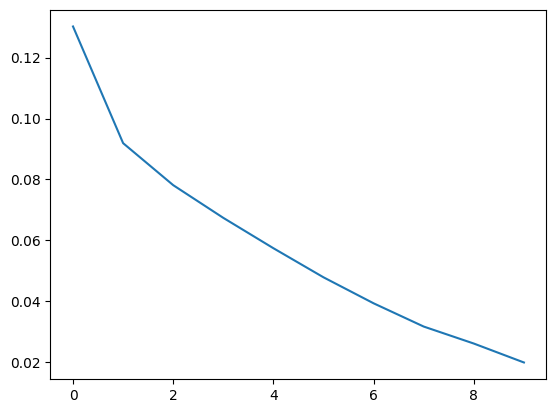

In [11]:
sns.lineplot(train_losses)

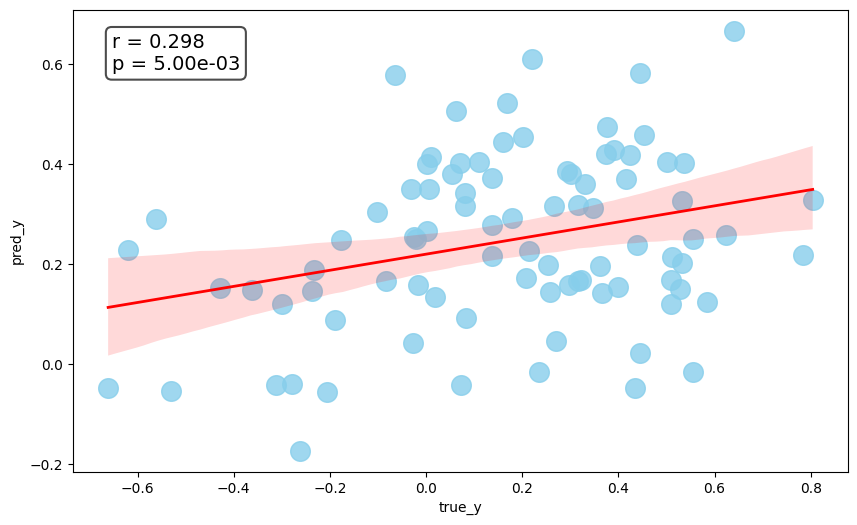

In [12]:
plots.linear_corr_plot(y_val_list,pred_y_list,'true_y','pred_y')

<Axes: >

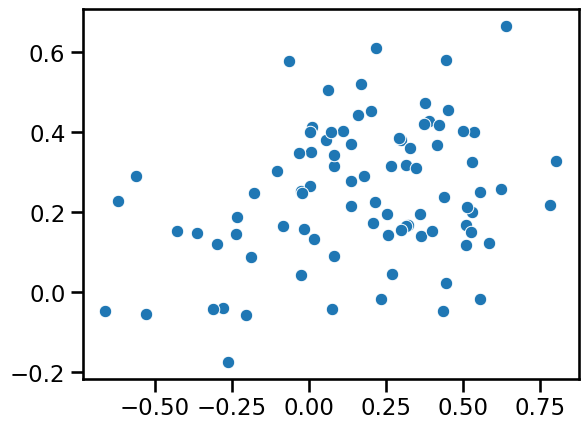

In [13]:
sns.scatterplot(x=y_val_list,y=pred_y_list)

In [ ]:
sns.lineplot(test_loss_list)

In [ ]:
sns.kdeplot(test_loss_list)

In [ ]:
eqx.tree_serialise_leaves('../params/model_inference.eqx',inference_model)

In [ ]:
test = eqx.tree_deserialise_leaves('../params/model_inference.eqx',inference_model)

In [ ]:
assert test == inference_model

In [ ]:
test

In [ ]:
inference_model

In [ ]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model_t, _ = esm.pretrained.esm2_t6_8M_UR50D()
model_esm2_t = esm2quinox.from_torch(torch_model)
model_aff_t, model_state_t = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2_t, key=model_key
)

# set to inference mode
inference_model_t = eqx.nn.inference_mode(model_aff_t)
inference_model_t = eqx.Partial(inference_model_t, state=model_state_t)

# load best inference pretrained model
best_model_aff_t = eqx.tree_deserialise_leaves('/home/kunzj/BindCraft_uva_internship/surr_model/params/model_inference.eqx',inference_model_t)


In [ ]:
if jnp.array_equal(best_model_aff_t.func.prot_projection.weight, inference_model.func.prot_projection.weight):
    print('hey')


In [ ]:
best_model_aff_t.func.pept_projection.weight